# Gaussian Parameters as Latent Variables — Visual Experiments

> **Goal:** Build intuition for a structured latent state made of Gaussian primitives: what the state stores, how a deterministic decoder turns it into an image, why local parameter edits are semantically meaningful, and why set-based latents behave differently from one dense vector.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **State to image** | What does a Gaussian latent state look like before it is rendered? |
| 2 | **Parameter interventions** | How do edits to mean, covariance, opacity, and color affect the decoded observation? |
| 3 | **Transition in Gaussian space** | Why is rolling forward structured state often easier to interpret than predicting pixels directly? |
| 4 | **Set semantics** | Why should the latent be treated as a set rather than an ordered list? |
| 5 | **Variable cardinality** | Why do split and merge operations matter for a Gaussian latent space? |

---
**Linked theory:** [research/10-gaussian-parameters-latent-variable.md](../research/10-gaussian-parameters-latent-variable.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.30,
})

print('Setup complete.')

Setup complete.


### What you see

1. **What the output shows:** A short setup message confirming the plotting environment is ready.
2. **Why it matters:** This notebook uses only NumPy and Matplotlib because the concept itself is structural. We do not need heavy dependencies to understand what the latent state stores.
3. **What to take away:** The visual story here is about state design, not about a specific training framework.

---
## A tiny Gaussian-state decoder

The helpers below implement a toy but meaningful decoder:

1. Each latent token stores a 2D mean, covariance, depth, opacity, and RGB color.
2. The decoder sorts tokens by depth.
3. Each token paints a soft Gaussian footprint over the image.
4. Front-to-back alpha compositing produces the final observation.

This is a 2D teaching version of the same core idea behind Gaussian-centric latent spaces: a structured state is rendered by geometry plus compositing, not by an opaque neural decoder.

In [2]:
WIDTH, HEIGHT = 192, 144
MIN_ALPHA = 1.0 / 255.0
SIGMA_LEVEL = 2.5


def make_token(gid, mean, cov, depth, opacity, color):
    cov = np.asarray(cov, dtype=float)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    return {
        'id': gid,
        'mean': np.asarray(mean, dtype=float),
        'cov': cov,
        'inv_cov': np.linalg.inv(cov),
        'depth': float(depth),
        'opacity': float(opacity),
        'color': np.asarray(color, dtype=float),
        'angle': angle,
        'axes': 2.0 * SIGMA_LEVEL * np.sqrt(np.maximum(eigvals, 1e-9)),
    }


def alpha_map(token, xs, ys):
    dx = xs - token['mean'][0]
    dy = ys - token['mean'][1]
    inv = token['inv_cov']
    quad = inv[0, 0] * dx * dx + 2.0 * inv[0, 1] * dx * dy + inv[1, 1] * dy * dy
    alpha = token['opacity'] * np.exp(-0.5 * quad)
    alpha = np.where(alpha >= MIN_ALPHA, np.minimum(alpha, 0.99), 0.0)
    return alpha


def render_state(tokens, width=WIDTH, height=HEIGHT, background=(1.0, 1.0, 1.0)):
    xs, ys = np.meshgrid(np.arange(width), np.arange(height))
    image = np.zeros((height, width, 3), dtype=float)
    transmittance = np.ones((height, width), dtype=float)
    for token in sorted(tokens, key=lambda item: item['depth']):
        alpha = alpha_map(token, xs, ys)
        image += transmittance[..., None] * alpha[..., None] * token['color'][None, None, :]
        transmittance *= (1.0 - alpha)
    background = np.asarray(background, dtype=float)
    image += transmittance[..., None] * background[None, None, :]
    return np.clip(image, 0.0, 1.0), transmittance


def draw_tokens(ax, tokens, width=WIDTH, height=HEIGHT, with_labels=True):
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect('equal')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    for token in tokens:
        ellipse = Ellipse(
            xy=token['mean'],
            width=token['axes'][0],
            height=token['axes'][1],
            angle=token['angle'],
            facecolor=token['color'],
            edgecolor=token['color'],
            linewidth=2.0,
            alpha=0.22,
        )
        ax.add_patch(ellipse)
        ax.scatter([token['mean'][0]], [token['mean'][1]], color=token['color'], s=34)
        if with_labels:
            ax.text(
                token['mean'][0] + 3,
                token['mean'][1] - 4,
                f"T{token['id']}\nz={token['depth']:.1f}",
                fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor=token['color'], alpha=0.85),
            )


def state_rows(tokens):
    rows = []
    for token in tokens:
        rows.append([
            f"T{token['id']}",
            f"({token['mean'][0]:.0f}, {token['mean'][1]:.0f})",
            f"{np.trace(token['cov']):.1f}",
            f"{token['depth']:.1f}",
            f"{token['opacity']:.2f}",
            f"({token['color'][0]:.2f}, {token['color'][1]:.2f}, {token['color'][2]:.2f})",
        ])
    return rows


def difference_map(image_a, image_b):
    return np.linalg.norm(image_a - image_b, axis=-1)


def clone_state(tokens):
    cloned = []
    for token in tokens:
        cloned.append(make_token(token['id'], token['mean'].copy(), token['cov'].copy(), token['depth'], token['opacity'], token['color'].copy()))
    return cloned


base_state = [
    make_token(0, mean=(46, 48),  cov=[[95, 18], [18, 44]], depth=1.2, opacity=0.78, color=(0.92, 0.36, 0.31)),
    make_token(1, mean=(112, 76), cov=[[56, -14], [-14, 92]], depth=1.9, opacity=0.72, color=(0.27, 0.58, 0.92)),
    make_token(2, mean=(154, 60), cov=[[70, 0], [0, 34]], depth=1.5, opacity=0.76, color=(0.30, 0.74, 0.42)),
    make_token(3, mean=(128, 112), cov=[[48, 20], [20, 48]], depth=2.6, opacity=0.84, color=(0.95, 0.74, 0.22)),
]

print('Gaussian-state helpers ready.')

Gaussian-state helpers ready.


### What you see

1. **What the output shows:** A setup message confirming the token representation and deterministic decoder are loaded.
2. **Why it matters:** The latent state already has enough structure to generate an observation. No learned image decoder is required in this toy setup.
3. **What to take away:** This is the central design shift of the note: the latent is a set of explicit primitives rather than a single dense feature vector.

---
## Experiment 1: A structured Gaussian state can be inspected before it is rendered

**Question:** What exactly lives inside the latent state?

A Gaussian-centric latent state is not just an embedding. It is a set of tokens with fields that already mean something: position, shape, opacity, depth, and appearance. We will show the tokens directly next to the decoded image.

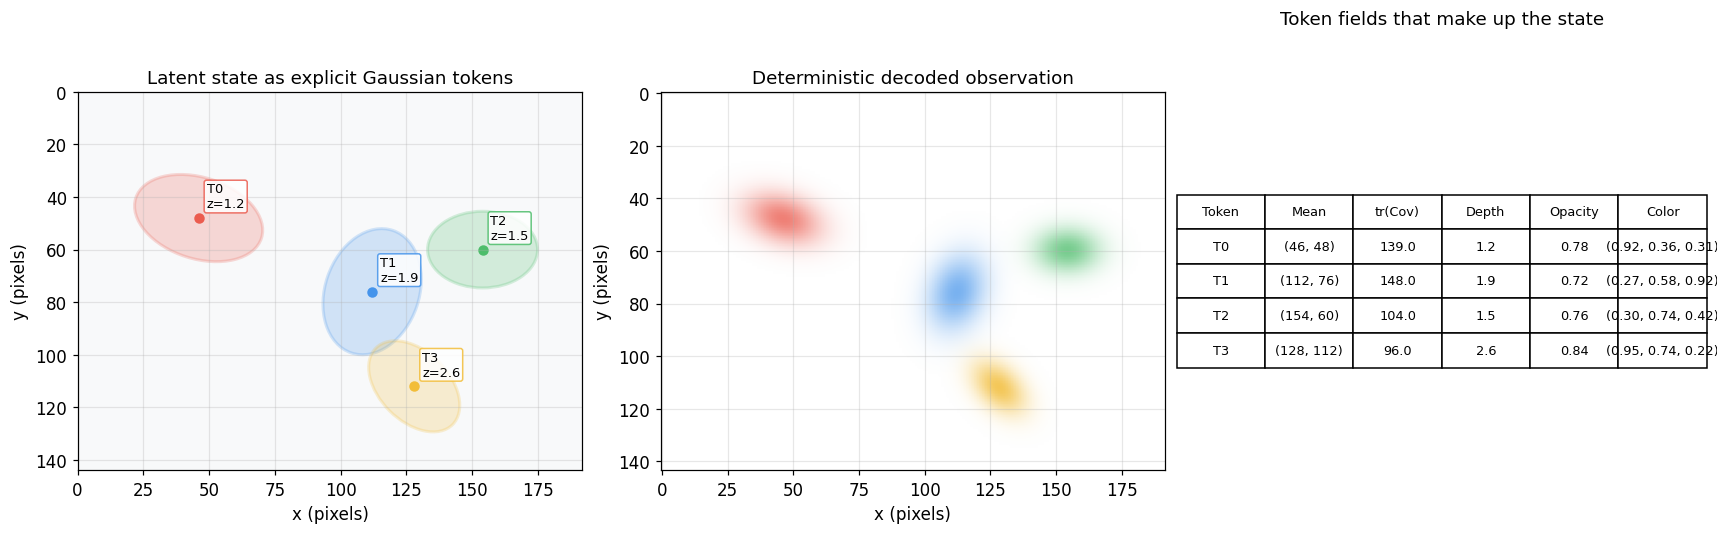

In [3]:
base_image, base_T = render_state(base_state)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
draw_tokens(axes[0], base_state)
axes[0].set_title('Latent state as explicit Gaussian tokens')

axes[1].imshow(base_image, origin='upper')
axes[1].set_title('Deterministic decoded observation')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')

axes[2].axis('off')
columns = ['Token', 'Mean', 'tr(Cov)', 'Depth', 'Opacity', 'Color']
table = axes[2].table(cellText=state_rows(base_state), colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8.4)
table.scale(1.05, 1.55)
axes[2].set_title('Token fields that make up the state')
plt.show()

### What you see

1. **What the output shows:** The left panel displays the latent tokens themselves, the middle panel shows the rendered image, and the table lists the parameters stored by each token.
2. **Why it looks this way:** The observation is a deterministic consequence of the state fields. Mean and covariance define geometry, opacity controls how strongly each token contributes, and color defines appearance.
3. **What to take away:** This latent is inspectable before decoding. That is the main conceptual difference from a dense vector latent whose individual coordinates usually have no direct physical interpretation.

---
## Experiment 2: Editing one parameter changes the observation in a local, meaningful way

**Question:** Why is a Gaussian latent space easier to manipulate?

We will edit a single token four different ways: move its mean, stretch its covariance, lower its opacity, and change its color. The resulting images and difference maps show whether each parameter has a clear semantic role.

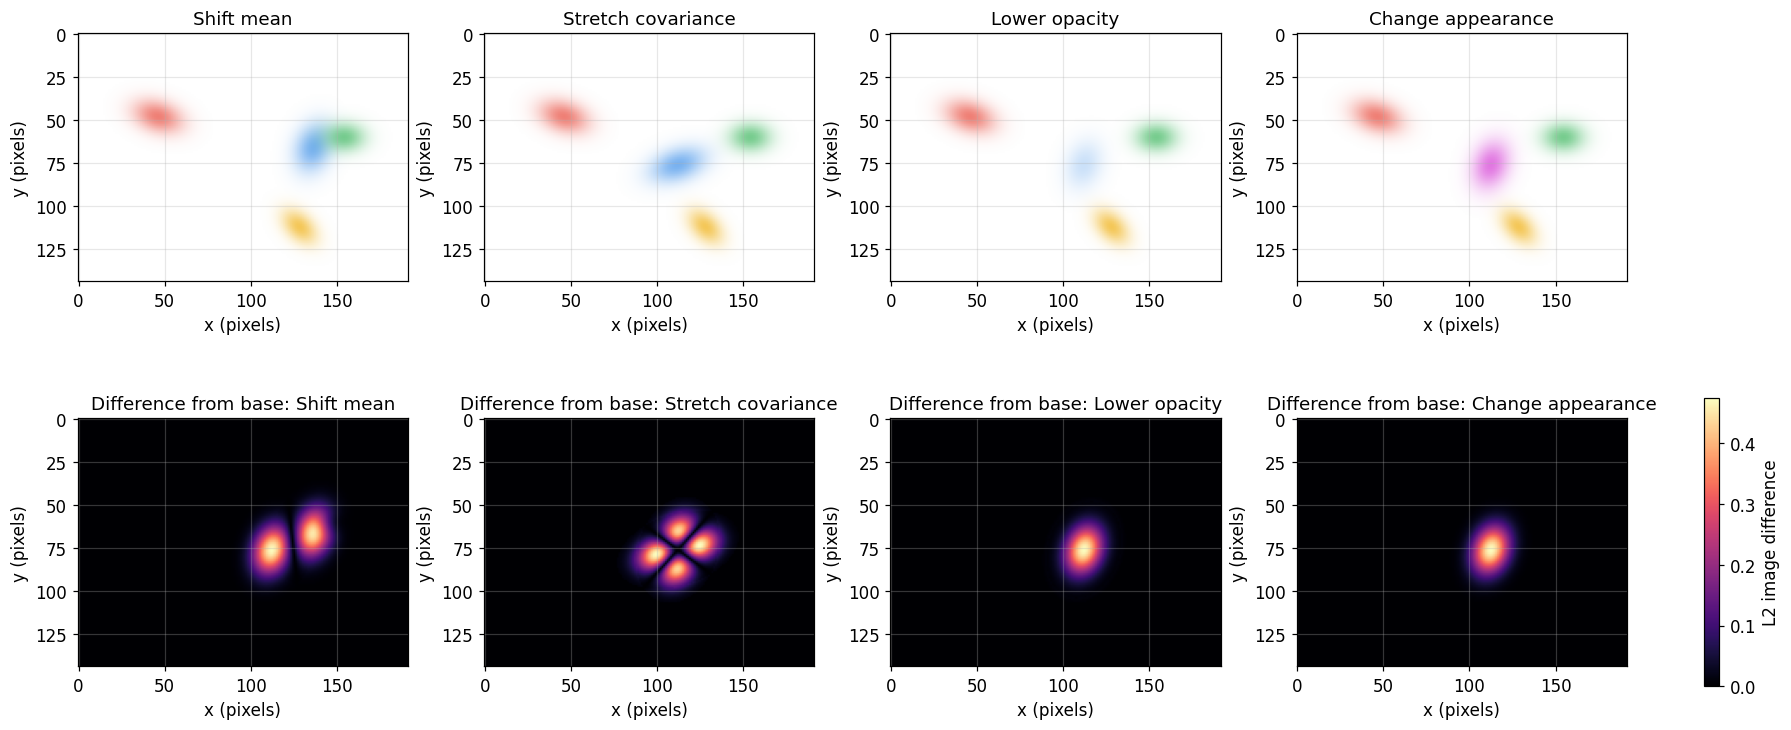

In [4]:
variants = []

moved = clone_state(base_state)
moved[1]['mean'] = moved[1]['mean'] + np.array([24.0, -10.0])
variants.append(('Shift mean', moved))

stretched = clone_state(base_state)
stretched[1]['cov'] = np.array([[120, -26], [-26, 50]], dtype=float)
stretched[1]['inv_cov'] = np.linalg.inv(stretched[1]['cov'])
eigvals, eigvecs = np.linalg.eigh(stretched[1]['cov'])
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
stretched[1]['axes'] = 2.0 * SIGMA_LEVEL * np.sqrt(np.maximum(eigvals, 1e-9))
stretched[1]['angle'] = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
variants.append(('Stretch covariance', stretched))

faded = clone_state(base_state)
faded[1]['opacity'] = 0.28
variants.append(('Lower opacity', faded))

recolored = clone_state(base_state)
recolored[1]['color'] = np.array([0.84, 0.26, 0.84])
variants.append(('Change appearance', recolored))

fig, axes = plt.subplots(2, 4, figsize=(16.2, 7.0), constrained_layout=True)
for column, (title, state_variant) in enumerate(variants):
    image_variant, _ = render_state(state_variant)
    diff = difference_map(image_variant, base_image)
    axes[0, column].imshow(image_variant, origin='upper')
    axes[0, column].set_title(title)
    axes[0, column].set_xlabel('x (pixels)')
    axes[0, column].set_ylabel('y (pixels)')
    im = axes[1, column].imshow(diff, origin='upper', cmap='magma')
    axes[1, column].set_title(f'Difference from base: {title}')
    axes[1, column].set_xlabel('x (pixels)')
    axes[1, column].set_ylabel('y (pixels)')
fig.colorbar(im, ax=axes[1, :], shrink=0.78, label='L2 image difference')
plt.show()

### What you see

1. **What the output shows:** Changing the mean moves one blob, changing covariance stretches its footprint, lowering opacity weakens its contribution, and changing color alters appearance without moving geometry. The difference maps remain concentrated near the edited token.
2. **Why it looks this way:** Each parameter controls one semantic aspect of the token. The decoder translates those parameter changes into local observation changes instead of global, entangled image distortions.
3. **What to take away:** This is why Gaussian parameters make attractive latent variables. They support localized, interpretable interventions rather than opaque coordinate tweaks.

---
## Experiment 3: Transition in Gaussian space is easy to describe and easy to audit

**Question:** Why is state rollout in Gaussian space appealing for world modeling?

We will define a tiny action-conditioned transition: one token moves to the right and slightly upward while becoming narrower. Instead of predicting future pixels directly, we update token parameters and let the decoder render the consequences.

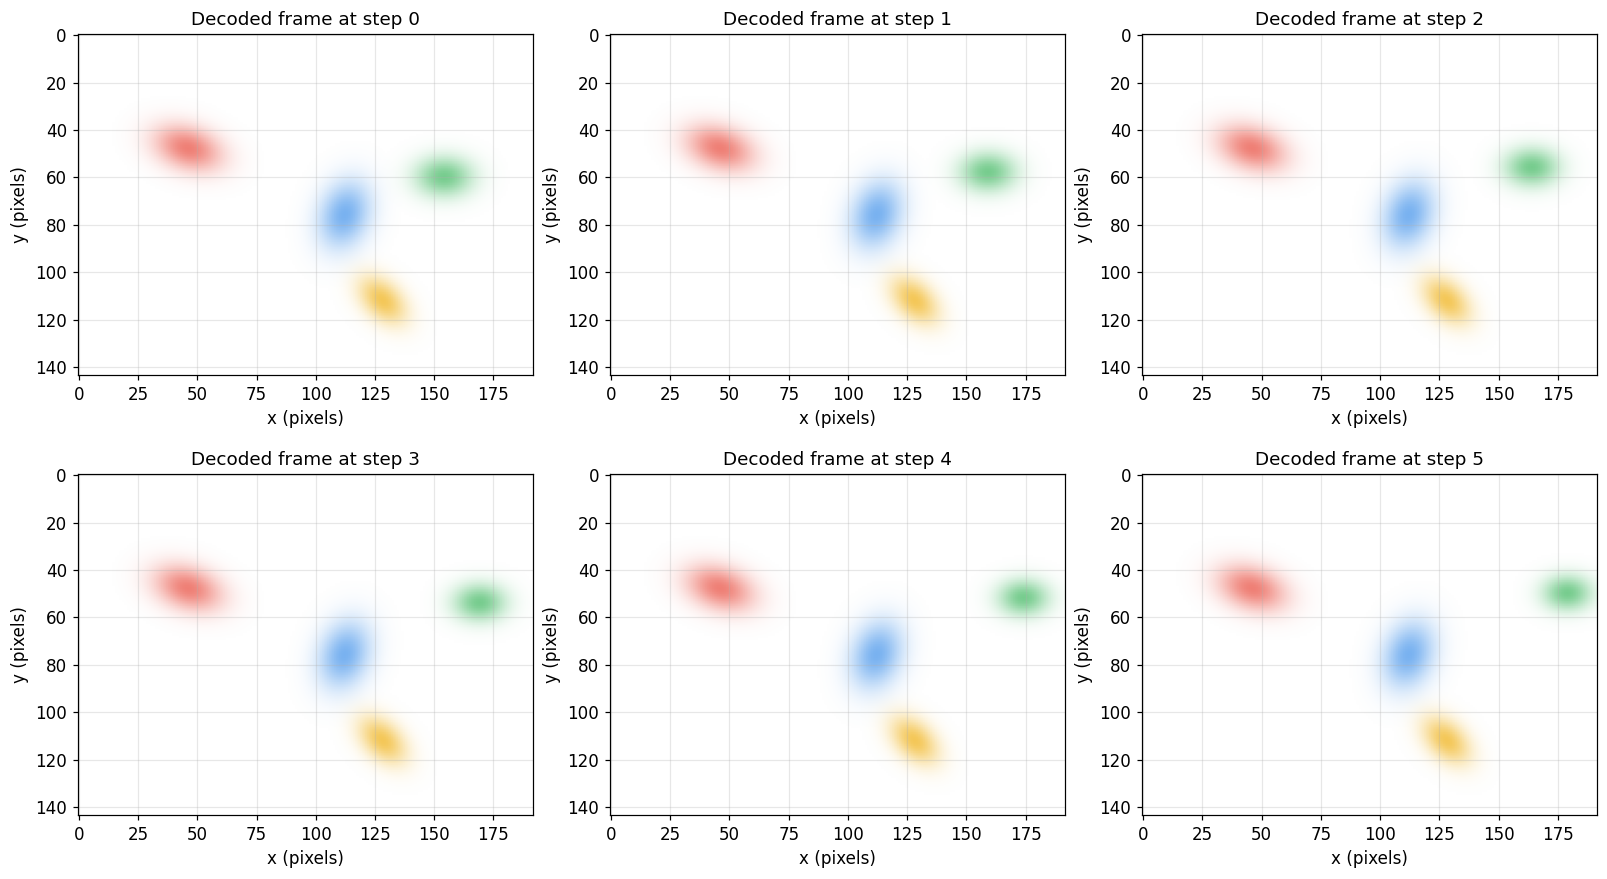

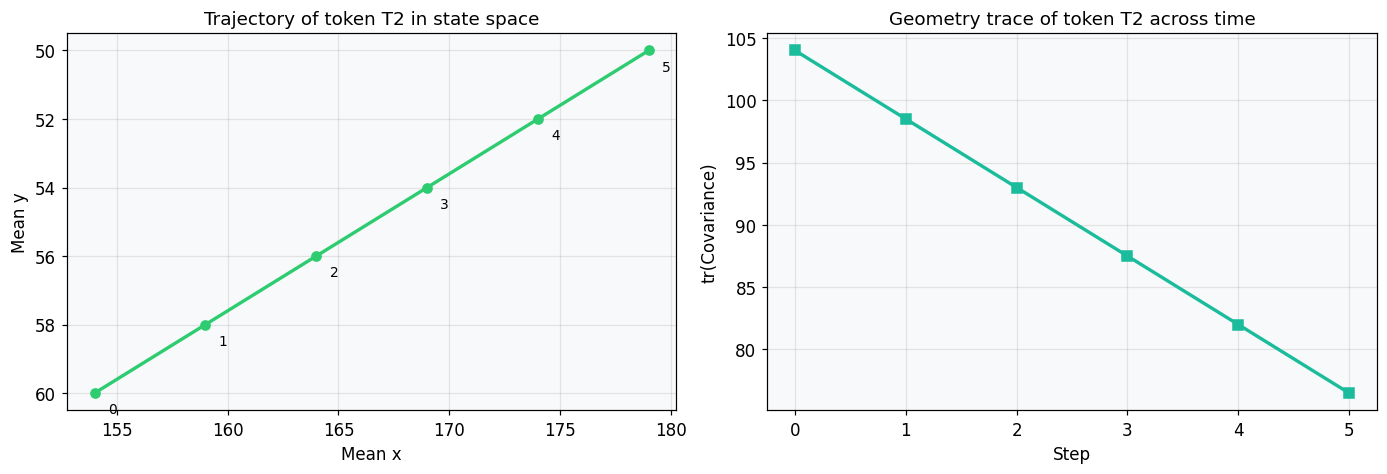

In [5]:
rollout_states = []
current = clone_state(base_state)
for step in range(6):
    rollout_states.append(clone_state(current))
    current[2]['mean'] = current[2]['mean'] + np.array([5.0, -2.0])
    new_cov = current[2]['cov'] + np.array([[-4.0, 0.0], [0.0, -1.5]])
    new_cov[0, 0] = max(new_cov[0, 0], 18.0)
    new_cov[1, 1] = max(new_cov[1, 1], 14.0)
    current[2]['cov'] = new_cov
    current[2]['inv_cov'] = np.linalg.inv(new_cov)
    eigvals, eigvecs = np.linalg.eigh(new_cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    current[2]['axes'] = 2.0 * SIGMA_LEVEL * np.sqrt(np.maximum(eigvals, 1e-9))
    current[2]['angle'] = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.0), constrained_layout=True)
for ax, state, step in zip(axes.flat, rollout_states, range(len(rollout_states))):
    image, _ = render_state(state)
    ax.imshow(image, origin='upper')
    ax.set_title(f'Decoded frame at step {step}')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
plt.show()

track_x = [state[2]['mean'][0] for state in rollout_states]
track_y = [state[2]['mean'][1] for state in rollout_states]
track_trace = [np.trace(state[2]['cov']) for state in rollout_states]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
axes[0].plot(track_x, track_y, marker='o', linewidth=2.2, color='#2ecc71')
for step, (x, y) in enumerate(zip(track_x, track_y)):
    axes[0].text(x + 0.6, y + 0.6, str(step), fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Trajectory of token T2 in state space')
axes[0].set_xlabel('Mean x')
axes[0].set_ylabel('Mean y')

axes[1].plot(range(len(track_trace)), track_trace, marker='s', linewidth=2.2, color='#1abc9c')
axes[1].set_title('Geometry trace of token T2 across time')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('tr(Covariance)')
plt.show()

### What you see

1. **What the output shows:** A single token moves and tightens over six steps, and the rendered scene changes accordingly. The second figure tracks the token's state trajectory directly through mean and covariance trace.
2. **Why it looks this way:** The rollout happens in latent space first, not in pixel space. The image sequence is a decoded consequence of structured parameter updates.
3. **What to take away:** Gaussian-centric state makes dynamics auditable. We can inspect *which primitive moved* and *how its geometry changed*, rather than only observing that a future frame looks different.

---
## Experiment 4: The latent should behave like a set, not like an ordered sequence

**Question:** Why is permutation symmetry a real modeling issue?

If the same Gaussian tokens are listed in a different order, the latent state should still represent the same scene. We will shuffle the token order and verify that the deterministic decoder produces the same observation as long as it sorts by depth internally.

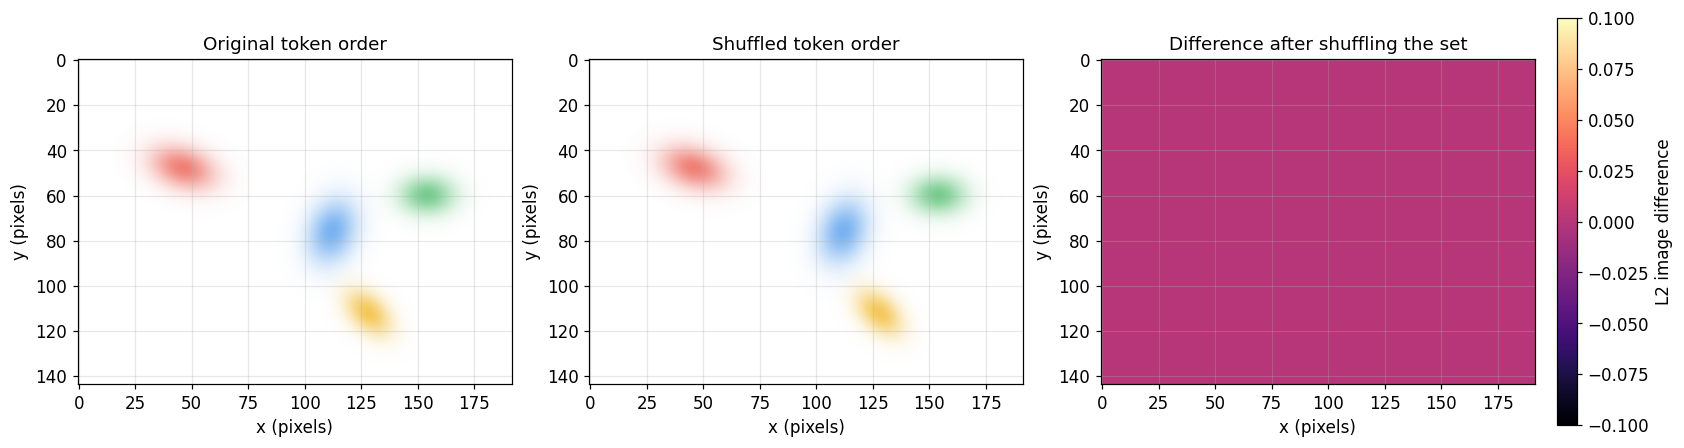

Original order : [0, 1, 2, 3]
Shuffled order : [2, 0, 3, 1]
Maximum pixel difference after shuffle: 0.0


In [6]:
shuffled_indices = [2, 0, 3, 1]
shuffled_state = [clone_state(base_state)[index] for index in shuffled_indices]
shuffled_image, _ = render_state(shuffled_state)
perm_diff = difference_map(base_image, shuffled_image)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.6), constrained_layout=True)
axes[0].imshow(base_image, origin='upper')
axes[0].set_title('Original token order')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

axes[1].imshow(shuffled_image, origin='upper')
axes[1].set_title('Shuffled token order')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')

im = axes[2].imshow(perm_diff, origin='upper', cmap='magma')
axes[2].set_title('Difference after shuffling the set')
axes[2].set_xlabel('x (pixels)')
axes[2].set_ylabel('y (pixels)')
fig.colorbar(im, ax=axes[2], shrink=0.82, label='L2 image difference')
plt.show()

print('Original order :', [token['id'] for token in base_state])
print('Shuffled order :', [token['id'] for token in shuffled_state])
print('Maximum pixel difference after shuffle:', float(np.max(perm_diff)))

### What you see

1. **What the output shows:** The rendered images are the same after shuffling the token order, and the difference map is numerically zero up to floating-point noise.
2. **Why it looks this way:** The latent meaning comes from the *set of tokens*, not from their storage order. A decoder or transition model that accidentally treats token position in a list as semantic information would break this property.
3. **What to take away:** Set structure is not a small implementation detail. It is part of the mathematical design of a Gaussian latent space.

---
## Experiment 5: Variable cardinality enables split and merge behavior

**Question:** Why is a fixed-size latent vector an awkward fit for Gaussian primitives?

We will approximate a target observation first with one wide Gaussian and then with two smaller Gaussians. The second state uses more tokens, but it should model the same region more precisely. This is the simplest visual argument for split operations.

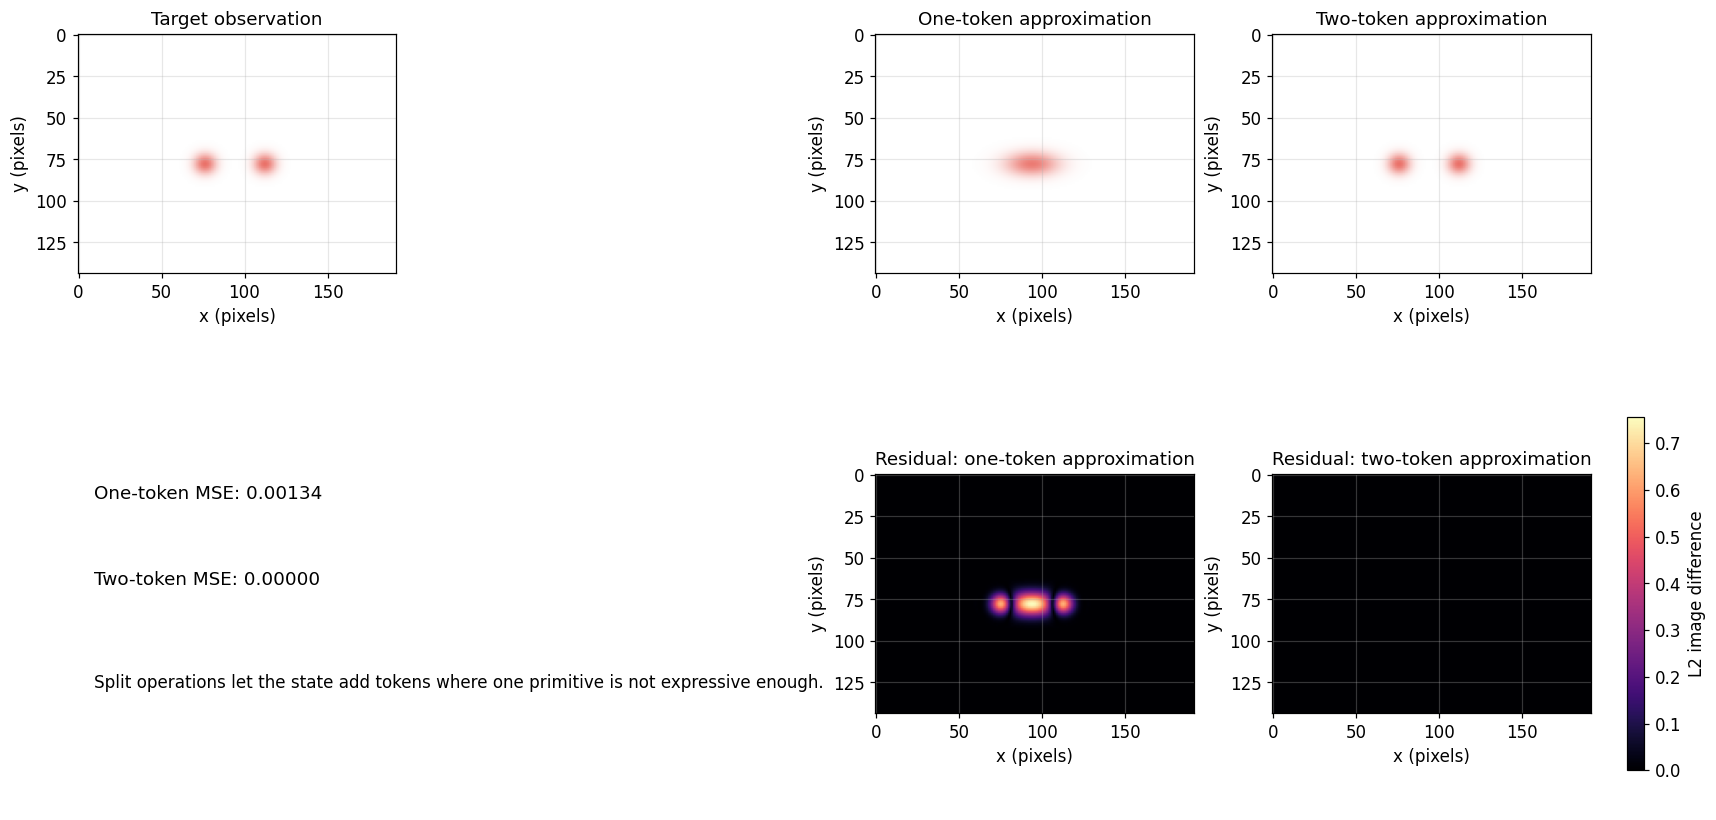

In [7]:
target_state = [
    make_token(0, mean=(76, 78), cov=[[22, 0], [0, 18]], depth=1.0, opacity=0.82, color=(0.90, 0.32, 0.28)),
    make_token(1, mean=(112, 78), cov=[[22, 0], [0, 18]], depth=1.0, opacity=0.82, color=(0.90, 0.32, 0.28)),
]
target_image, _ = render_state(target_state)

one_token_state = [
    make_token(0, mean=(94, 78), cov=[[120, 0], [0, 24]], depth=1.0, opacity=0.76, color=(0.90, 0.32, 0.28)),
]
two_token_state = clone_state(target_state)

one_image, _ = render_state(one_token_state)
two_image, _ = render_state(two_token_state)
err_one = difference_map(target_image, one_image)
err_two = difference_map(target_image, two_image)

mse_one = float(np.mean((target_image - one_image) ** 2))
mse_two = float(np.mean((target_image - two_image) ** 2))

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.0), constrained_layout=True)
axes[0, 0].imshow(target_image, origin='upper')
axes[0, 0].set_title('Target observation')
axes[0, 1].imshow(one_image, origin='upper')
axes[0, 1].set_title('One-token approximation')
axes[0, 2].imshow(two_image, origin='upper')
axes[0, 2].set_title('Two-token approximation')

im1 = axes[1, 1].imshow(err_one, origin='upper', cmap='magma')
axes[1, 0].axis('off')
axes[1, 0].text(0.05, 0.72, f'One-token MSE: {mse_one:.5f}', fontsize=12)
axes[1, 0].text(0.05, 0.52, f'Two-token MSE: {mse_two:.5f}', fontsize=12)
axes[1, 0].text(0.05, 0.28, 'Split operations let the state add tokens where one primitive is not expressive enough.', fontsize=11, wrap=True)
axes[1, 1].set_title('Residual: one-token approximation')
axes[1, 2].imshow(err_two, origin='upper', cmap='magma')
axes[1, 2].set_title('Residual: two-token approximation')
for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 1], axes[1, 2]]:
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
fig.colorbar(im1, ax=axes[1, 1:], shrink=0.82, label='L2 image difference')
plt.show()

### What you see

1. **What the output shows:** One wide Gaussian can only blur across the two target modes, while two tokens match the target almost exactly. The residual map becomes much smaller once the latent state is allowed to increase its cardinality.
2. **Why it looks this way:** A single primitive has limited local expressivity. Split operations let the state allocate more detail exactly where the scene demands it.
3. **What to take away:** A Gaussian latent space is naturally variable-sized. That flexibility is powerful, but it also makes transition modeling harder because the number of latent tokens can change over time.

---
## Summary / Key Takeaways

- **A Gaussian latent state is structured before decoding.** Each token already stores interpretable geometry and appearance fields.
- **The decoder can be almost fully analytic.** Rendering follows from compositing explicit primitives rather than reconstructing pixels with a large neural decoder.
- **Parameter edits are semantic and local.** Mean, covariance, opacity, and color each affect the observation in predictable ways.
- **Dynamics become more auditable.** State rollout can be described as movement and deformation of tokens rather than opaque latent drift.
- **Set structure and variable cardinality are essential.** They make Gaussian latents expressive and manipulable, but they also introduce the modeling challenges that fixed-size vector latents do not have.